Inference-Time Decoding Controls
===

**Dr Chao Shu (chao.shu@qmul.ac.uk)**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display, HTML
import warnings
warnings.filterwarnings('ignore')

from utils import get_completion, display_responses, LLMModels

from dotenv import load_dotenv
load_dotenv()  # Load environment variables from .env file

# Use a clean style for plots
plt.rcParams.update({
    'figure.figsize': (10, 4),
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

## Set Up Default LLM
---

In [2]:
# Set default model configuration
model_api_config = LLMModels.OLLAMA_GEMMA_3_1B.value
model_api_config.provider = "openai"
model_api_config.base_url = "http://localhost:11434/v1"  # Set the base URL that supports logprobs and top_logprobs
model_api_config.stream = False  # Enable streaming responses
model_api_config.temperature = 0.0
model_api_config.top_p = 1.0
model_api_config.max_tokens = 64
model_api_config.logprobs = True
model_api_config.top_logprobs = 5

### Helper Function Test

In [3]:
content, response = get_completion(user_prompt="Hello!", model_api_config=model_api_config)
print("✅ Received Response:", content.strip())

✅ Received Response: Hello there! How's your day going so far? 😊 

Is there anything you'd like to chat about or any help I can offer?


## Introduction to Inference-Time Decoding Controls
---

Inference-time decoding controls are settings used **at generation time** to shape how an LLM produces text, without retraining the model.

Common controls include:

- **Temperature**: adjusts randomness (lower = more deterministic, higher = more diverse).
- **Top-p / Top-k**: limits token sampling to the most likely candidates.
- **Max tokens**: caps response length.
- **Repetition penalty**: reduces repeated words/phrases.
- **Stop sequences**: tells the model where to stop.

These parameters help balance **accuracy, creativity, consistency, and cost/latency** for different tasks.

### The Autoregressive Generation Pipeline

LLMs generate text **one token at a time**. At each step, the model:

1. **Encodes** all previous tokens (prompt + already generated tokens)
2. **Produces logits** — a raw score $z_i$ for every token $i$ in the vocabulary (typically 30,000–150,000 tokens)
3. **Converts logits to probabilities** via the **softmax** function:

$$P(x_i) = \frac{e^{z_i}}{\sum_{j=1}^{V} e^{z_j}}$$

where $V$ is the vocabulary size.

4. **Samples** a token from this probability distribution (or picks the most probable one)
5. **Repeats** until a stopping condition is met

The inference parameters we'll study control **steps 3–5** of this pipeline.

APIs return **log probabilities (logprobs)** instead of raw probabilities because:
- Probabilities can be extremely small (e.g., $10^{-30}$), causing floating-point underflow
- Log probabilities are additive: $\log P(A, B) = \log P(A) + \log P(B)$

To convert between them:

$$\text{logprob} = \ln(P) \quad \Longleftrightarrow \quad P = e^{\text{logprob}}$$

For example, `logprob = -0.693` means $P = e^{-0.693} \approx 0.5$ (50% probability).

### 🧑‍🏫 Demo: Visualising Token Probabilities from Real Logprobs

Let's examine the token probabilities for a given prompt (with `temperature=0`).

In [4]:
# Request logprobs for a simple completion
content, response = get_completion(user_prompt="The capital of France is", model_api_config=model_api_config)

print("Generated text:", response.choices[0].message.content.strip())
print()

# Extract and display logprobs for each generated token
if response.choices[0].logprobs and response.choices[0].logprobs.content:
    for i, token_info in enumerate(response.choices[0].logprobs.content):
        print(f"--- Token {i+1}: '{token_info.token}' (logprob: {token_info.logprob:.4f}, prob: {np.exp(token_info.logprob):.4f}) ---")
        if token_info.top_logprobs:
            for alt in token_info.top_logprobs:
                prob = np.exp(alt.logprob)
                print(f"  '{alt.token}': logprob={alt.logprob:.4f}, prob={prob:.4f} ({prob*100:.1f}%)")
else:
    print("⚠️ Logprobs not returned. Ensure Ollama v0.12.11+ is installed.")

Generated text: Paris! 

It’s the capital of France. 😊 

Do you want to know more about Paris?

--- Token 1: 'Paris' (logprob: -0.0792, prob: 0.9239) ---
  'Paris': logprob=-0.0792, prob=0.9239 (92.4%)
  'The': logprob=-2.5758, prob=0.0761 (7.6%)
  'Just': logprob=-11.1482, prob=0.0000 (0.0%)
  'France': logprob=-12.6315, prob=0.0000 (0.0%)
  '巴黎': logprob=-13.0733, prob=0.0000 (0.0%)
--- Token 2: '!' (logprob: -0.0344, prob: 0.9662) ---
  '!': logprob=-0.0344, prob=0.9662 (96.6%)
  '.': logprob=-3.8994, prob=0.0203 (2.0%)
  '<end_of_turn>': logprob=-4.3379, prob=0.0131 (1.3%)
  '
': logprob=-7.9264, prob=0.0004 (0.0%)
  ' is': logprob=-10.1841, prob=0.0000 (0.0%)
--- Token 3: ' ' (logprob: -0.0104, prob: 0.9896) ---
  ' ': logprob=-0.0104, prob=0.9896 (99.0%)
  ' 😊': logprob=-4.7143, prob=0.0090 (0.9%)
  '
': logprob=-7.2562, prob=0.0007 (0.1%)
  '

': logprob=-7.3187, prob=0.0007 (0.1%)
  ' ❤️': logprob=-10.9589, prob=0.0000 (0.0%)
--- Token 4: '

' (logprob: -0.2160, prob: 0.8057) -

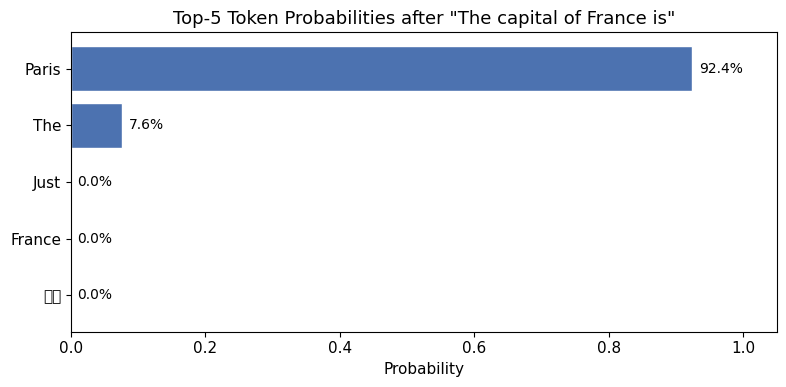

In [5]:
# Visualise the top token probabilities for the first generated token
if response.choices[0].logprobs and response.choices[0].logprobs.content:
    first_token = response.choices[0].logprobs.content[0]
    if first_token.top_logprobs:
        tokens = [t.token.strip() or repr(t.token) for t in first_token.top_logprobs]
        probs = [np.exp(t.logprob) for t in first_token.top_logprobs]

        fig, ax = plt.subplots(figsize=(8, 4))
        bars = ax.barh(tokens[::-1], probs[::-1], color='#4C72B0', edgecolor='white')
        ax.set_xlabel('Probability')
        ax.set_title(f'Top-5 Token Probabilities after "The capital of France is"')
        ax.set_xlim(0, 1.05)

        for bar, p in zip(bars, probs[::-1]):
            ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                    f'{p:.1%}', va='center', fontsize=10)

        plt.tight_layout()
        plt.show()

## Temperature
---

Temperature $T$ modifies the softmax function by scaling the logits before applying softmax:

$$P(x_i \mid T) = \frac{e^{z_i / T}}{\sum_{j=1}^{V} e^{z_j / T}}$$

- **$T \to 0$** (low temperature): The distribution becomes **sharper** — the highest-probability token dominates. When $T=0$, this is equivalent to **greedy decoding** (always pick the argmax).
- **$T = 1$**: The original probability distribution from the model's softmax is used unchanged.
- **$T > 1$** (high temperature): The distribution becomes **flatter** — all tokens become more equally likely. In the limit $T \to \infty$, this approaches a **uniform distribution**.

### Example

Consider two logits $z_1 = 2$ and $z_2 = 1$. At $T = 1$:
$$P(x_1) = \frac{e^{2}}{e^{2} + e^{1}} \approx 0.73$$

At $T = 0.5$ (sharper):
$$P(x_1) = \frac{e^{2/0.5}}{e^{2/0.5} + e^{1/0.5}} = \frac{e^{4}}{e^{4} + e^{2}} \approx 0.88$$

At $T = 2$ (flatter):
$$P(x_1) = \frac{e^{2/2}}{e^{2/2} + e^{1/2}} = \frac{e^{1}}{e^{1} + e^{0.5}} \approx 0.62$$


### 🧑‍🏫 Demo: Temperature's Effect on Probabilities (Simulated)

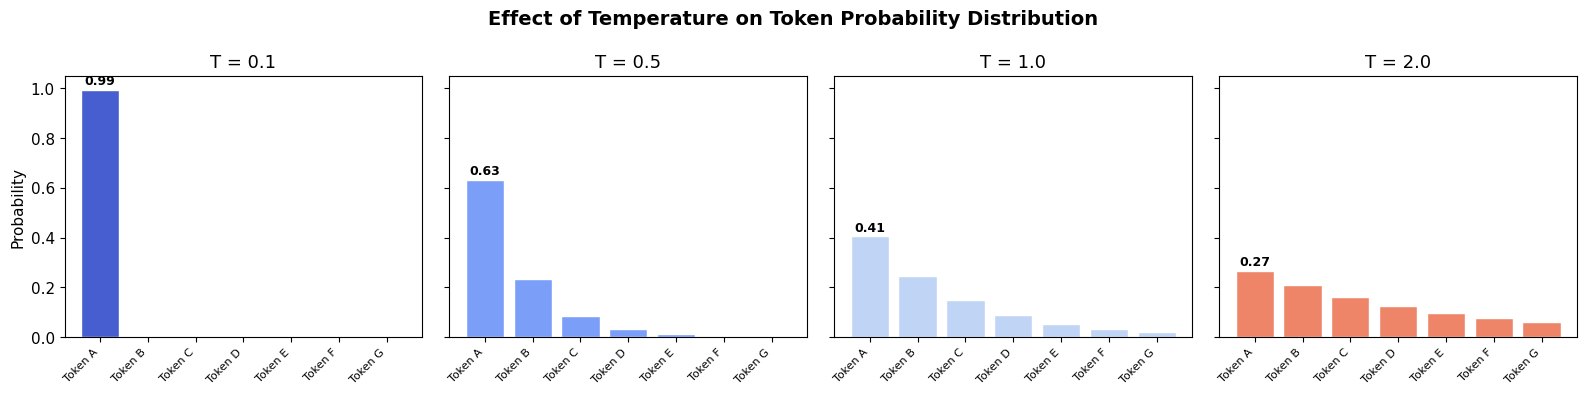

In [6]:
# Simulate temperature scaling on example logits
logits = np.array([2.0, 1.5, 1.0, 0.5, 0.0, -0.5, -1.0])
token_labels = ['Token A', 'Token B', 'Token C', 'Token D', 'Token E', 'Token F', 'Token G']
temperatures = [0.1, 0.5, 1.0, 2.0]

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
fig.suptitle('Effect of Temperature on Token Probability Distribution', fontsize=14, fontweight='bold')

for ax, T in zip(axes, temperatures):
    scaled = logits / T
    probs = np.exp(scaled) / np.exp(scaled).sum()  # softmax
    bars = ax.bar(range(len(probs)), probs, color=plt.cm.coolwarm(T / 2.5), edgecolor='white')
    ax.set_title(f'T = {T}')
    ax.set_xticks(range(len(token_labels)))
    ax.set_xticklabels(token_labels, rotation=45, ha='right', fontsize=8)
    ax.set_ylim(0, 1.05)
    if T == temperatures[0]:
        ax.set_ylabel('Probability')
    # Annotate max
    max_idx = np.argmax(probs)
    ax.text(max_idx, probs[max_idx] + 0.02, f'{probs[max_idx]:.2f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

### 🧑‍🏫 Demo: Temperature with Real Model Outputs

In [7]:
# Compare model outputs at different temperatures
prompt = "Write a one-sentence description of the ocean:"
temperatures = [0.0, 0.5, 1.0, 1.5, 2.0, 5.0]

# Preserve config to avoid side effects on later cells
old_temp = model_api_config.temperature

print(f"Prompt: \"{prompt}\"\n")
print("=" * 80)
    
for temp in temperatures:
    print(f"\n🌡️ Temperature = {temp}")
    print("-" * 40)
    # Generate 3 samples at each temperature to show variance
    model_api_config.temperature = temp
    for i in range(3):
        content, response = get_completion(user_prompt=prompt, model_api_config=model_api_config)
        print(f"  Sample {i+1}: {content.strip()}")

# Restore original temperature
model_api_config.temperature = old_temp

Prompt: "Write a one-sentence description of the ocean:"


🌡️ Temperature = 0.0
----------------------------------------
  Sample 1: The ocean is a vast, dynamic body of saltwater that covers over 70% of the Earth’s surface, teeming with life and holding immense power and mystery.
  Sample 2: The ocean is a vast, dynamic body of saltwater that covers over 70% of the Earth’s surface, teeming with life and holding immense power and mystery.
  Sample 3: The ocean is a vast, dynamic body of saltwater that covers over 70% of the Earth’s surface, teeming with life and holding immense power and mystery.

🌡️ Temperature = 0.5
----------------------------------------
  Sample 1: The ocean is a vast, dynamic body of saltwater that covers over 70% of the Earth’s surface and sustains countless life forms.
  Sample 2: The ocean is a vast and powerful expanse of water covering over 70% of the Earth’s surface, teeming with life and holding countless mysteries.
  Sample 3: The ocean is a vast and myst

### 🧑‍🏫 Demo: Temperature's Effect on Real Logprobs

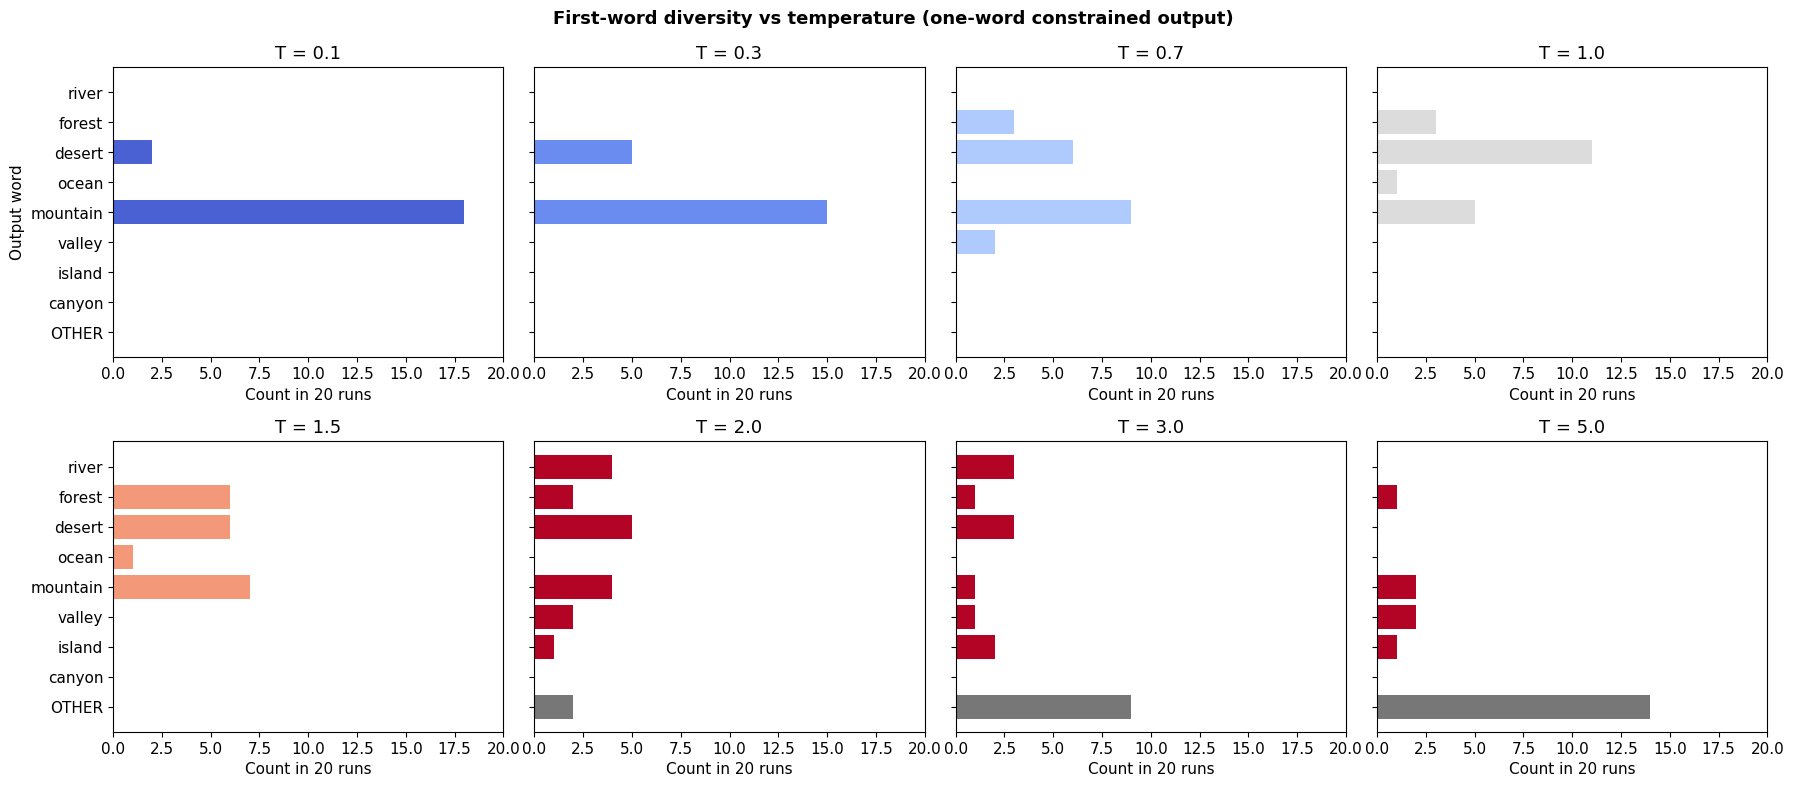

T=0.1: unique= 2, in-list=20/20, labels=desert, mountain
T=0.3: unique= 2, in-list=20/20, labels=desert, mountain
T=0.7: unique= 4, in-list=20/20, labels=desert, forest, mountain, valley
T=1.0: unique= 4, in-list=20/20, labels=desert, forest, mountain, ocean
T=1.5: unique= 4, in-list=20/20, labels=desert, forest, mountain, ocean
T=2.0: unique= 7, in-list=18/20, labels=OTHER, desert, forest, island, mountain, river, valley
T=3.0: unique= 7, in-list=11/20, labels=OTHER, desert, forest, island, mountain, river, valley
T=5.0: unique= 5, in-list= 6/20, labels=OTHER, forest, island, mountain, valley


In [8]:
# Better one-word temperature demo: force a single-word choice among multiple valid options
prompt = (
    "Return exactly ONE word and nothing else. "
    "The word MUST be chosen from this list: river, forest, desert, ocean, mountain, valley, island, canyon. "
    "Do not invent new words. Do not add punctuation."
)

temps = [0.1, 0.3, 0.7, 1.0, 1.5, 2.0, 3.0, 5.0]
samples_per_temp = 20
choices = ["river", "forest", "desert", "ocean", "mountain", "valley", "island", "canyon"]
plot_labels = choices + ["OTHER"]

# Preserve config to avoid side effects on later cells
old_temp = model_api_config.temperature
old_max_tokens = model_api_config.max_tokens

results = {t: [] for t in temps}

for temp in temps:
    model_api_config.temperature = temp
    model_api_config.max_tokens = 3
    for _ in range(samples_per_temp):
        content, _ = get_completion(user_prompt=prompt, model_api_config=model_api_config)
        token = content.strip().split()[0].lower().strip(".,!?;:\"'`()[]{}")
        if token not in choices:
            token = "OTHER"
        results[temp].append(token)

model_api_config.temperature = old_temp
model_api_config.max_tokens = old_max_tokens

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey=True)
fig.suptitle(
    "First-word diversity vs temperature (one-word constrained output)",
    fontsize=13,
    fontweight='bold'
 )

for ax, temp in zip(axes.flatten(), temps):
    counts = [results[temp].count(word) for word in plot_labels]
    colors = [plt.cm.coolwarm(min(temp / 2.0, 1.0))] * len(choices) + ["#777777"]
    ax.barh(plot_labels[::-1], counts[::-1], color=colors[::-1])
    ax.set_title(f"T = {temp}")
    ax.set_xlim(0, samples_per_temp)
    ax.set_xlabel("Count in 20 runs")
    if temp == temps[0]:
        ax.set_ylabel("Output word")

plt.tight_layout()
plt.show()

for temp in temps:
    uniq = sorted(set(results[temp]))
    in_vocab = sum(1 for w in results[temp] if w != "OTHER")
    print(
        f"T={temp:>3}: unique={len(uniq):2d}, in-list={in_vocab:2d}/{samples_per_temp}, "
        f"labels={', '.join(uniq)}"
    )

### 📝 Exercise 1: Temperature Exploration

**Task:** Use the `get_completion` helper to explore temperature effects.

1. Try the prompt `"Write a creative story starting with: 'Once upon a time in a land far away,'. Start writing immediately in your response."` at temperatures 0.0, 0.7, 1.2, 2.0 and 5.0
2. Generate 3 samples at each temperature
3. **Observe:** At which temperature do you start seeing noticeably different outputs across samples? At which temperature does the output become incoherent?

In [ ]:
# Set the prompt and temperatures
prompt = "Write a creative story starting with: 'Once upon a time in a land far away,'. Start writing immediately in your response."
temps = [0.0, 0.7, 1.2, 2.0, 5.0]

# Preserve config to avoid side effects on later cells
old_temp = model_api_config.temperature

for temp in temps:
    print(f"\n{'='*60}")
    print(f"🌡️ Temperature = {temp}")
    print('='*60)

    # TODO: Generate 3 samples at each temperature and print each of them

    for i in range(3):
        
        content, _ = " ", " "

        print(f"  Sample {i+1}: {content.strip()}")

# Restore original temperature
model_api_config.temperature = old_temp
    

## Top-p (Nucleus Sampling)
---

Top-p sampling (also called **nucleus sampling**), introduced by [Holtzman et al. (2020)](https://arxiv.org/abs/1904.09751), works by:

1. **Sorting** all tokens by probability in descending order
2. **Accumulating** probabilities until the cumulative sum reaches the threshold $p$
3. **Restricting** sampling to only those tokens (the "nucleus")
4. **Renormalising** the probabilities within the nucleus

Formally, define the nucleus as the smallest set $\mathcal{N}_p$ such that:

$$\sum_{x_i \in \mathcal{N}_p} P(x_i) \geq p$$

Then, the adjusted probability for sampling is:

$$P'(x_i) = \begin{cases} \frac{P(x_i)}{\sum_{x_j \in \mathcal{N}_p} P(x_j)} & \text{if } x_i \in \mathcal{N}_p \\ 0 & \text{otherwise} \end{cases}$$

**Interpretation:**
- **$p = 0.1$**: Only the very top tokens are considered → very focused output
- **$p = 0.9$**: Most of the probability mass is included → more diverse output
- **$p = 1.0$**: All tokens are considered → equivalent to no top-p filtering

**Top-p vs Temperature**
- **Temperature** reshapes the entire distribution (makes all tokens more/less likely)
- **Top-p** truncates the distribution (removes low-probability tokens entirely)
- They can be **combined**: temperature reshapes first, then top-p truncates

### Min-p

A related sampling strategy is min-p. `Min-p` dynamically adjusts the probability cutoff based on the confidence of the most likely token. You can find the introduction [here](https://github.com/huggingface/transformers/issues/27670).

> 💡 Note: 
> 
> The `min_p` parameter is not a standard or supported parameter in the official [OpenAI API](https://developers.openai.com/api/reference/overview). Some third-party, OpenAI-compatible servers (like [vLLM](https://docs.vllm.ai/en/v0.6.2/dev/sampling_params.html) and [Ollama](https://docs.ollama.com/api/generate)) have added it as an extra feature.

### 🧑‍🏫 Demo: Understanding Nucleus Sampling (Simulated)

Given probabilities of 9 tokens (Token A - I) are 0.35, 0.25, 0.15, 0.10, 0.05, 0.04, 0.03, 0.02, 0.01, respectively. Which tokens will be included in the candidate token list for sampling when `top_p` is set to:
1. `top_p = 0.5`
2. `top_p = 0.7`
3. `top_p = 0.9`

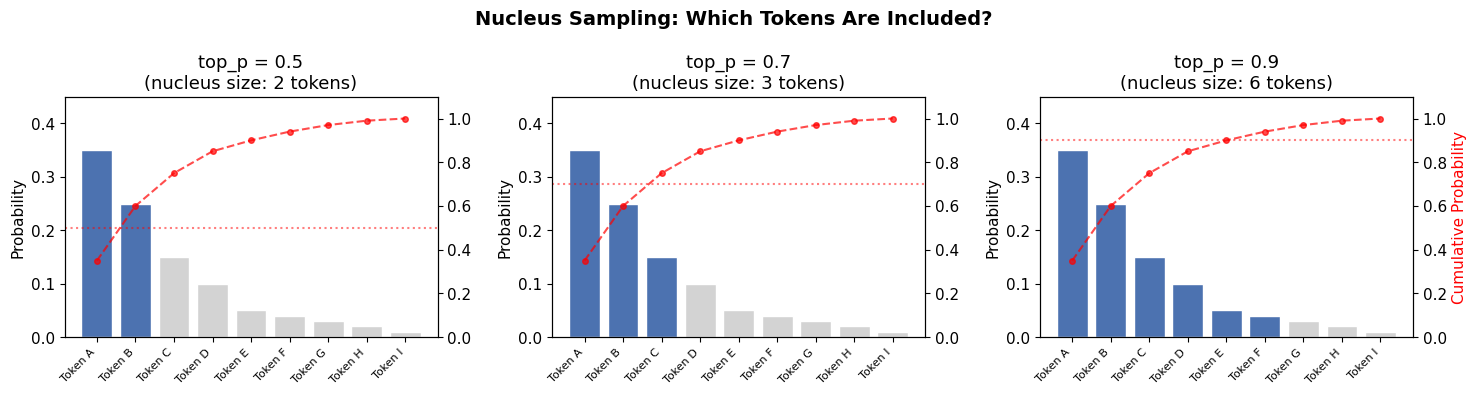

🔵 Blue = tokens IN the nucleus (will be sampled from)
⚪ Grey = tokens OUTSIDE the nucleus (probability set to 0)


In [10]:
# Simulate nucleus sampling
probs = np.array([0.35, 0.25, 0.15, 0.10, 0.05, 0.04, 0.03, 0.02, 0.01])
labels = [f'Token {chr(65+i)}' for i in range(len(probs))]
cumulative = np.cumsum(probs)

top_p_values = [0.5, 0.7, 0.9]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Nucleus Sampling: Which Tokens Are Included?', fontsize=14, fontweight='bold')

for ax, p in zip(axes, top_p_values):
    in_nucleus = cumulative <= p
    # Include the first token that pushes us over the threshold
    first_over = np.argmax(cumulative > p)
    in_nucleus[first_over] = True
    nucleus_size = in_nucleus.sum()

    colors = ['#4C72B0' if inc else '#D3D3D3' for inc in in_nucleus]
    bars = ax.bar(range(len(probs)), probs, color=colors, edgecolor='white')
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.set_title(f'top_p = {p}\n(nucleus size: {nucleus_size} tokens)')
    ax.set_ylabel('Probability')
    ax.set_ylim(0, 0.45)

    # Draw cumulative line
    ax2 = ax.twinx()
    ax2.plot(range(len(probs)), cumulative, 'r--o', markersize=4, alpha=0.7)
    ax2.axhline(y=p, color='red', linestyle=':', alpha=0.5)
    ax2.set_ylim(0, 1.1)
    if p == top_p_values[-1]:
        ax2.set_ylabel('Cumulative Probability', color='red')

plt.tight_layout()
plt.show()

print("🔵 Blue = tokens IN the nucleus (will be sampled from)")
print("⚪ Grey = tokens OUTSIDE the nucleus (probability set to 0)")

### 🧑‍🏫 Demo: Top-p with Real Model Outputs

Let's examine the model outputs with a fixed `temperature=1.0` but different `top_p`.

In [11]:
# Compare outputs at different top_p values
prompt = "The most interesting thing about artificial intelligence is"
top_p_vals = [0.1, 0.5, 0.9, 1.0]

print(f"Prompt: \"{prompt}\"\n")

# Preserve config to avoid side effects on later cells
old_temp = model_api_config.temperature
old_top_p = model_api_config.top_p

# Set temperature to 1.0 to allow more diversity and better see the effect of top_p
model_api_config.temperature = 1.0

for p in top_p_vals:
    print(f"\n🎯 top_p = {p}")
    print("-" * 50)

    # Adjust top_p
    model_api_config.top_p = p

    for i in range(3):
        content, resp = get_completion(user_prompt=prompt, model_api_config=model_api_config)
        print(f"  Sample {i+1}: {content.strip()}")

# Restore original top_p and temperature
model_api_config.temperature = old_temp
model_api_config.top_p = old_top_p

Prompt: "The most interesting thing about artificial intelligence is"


🎯 top_p = 0.1
--------------------------------------------------
  Sample 1: Okay, this is a fantastic and complex question! There's no single "most" interesting thing, as AI's potential is incredibly vast and fascinating. However, if I had to pick *one* that I think truly captures the current excitement and potential, it would be **the emergent complexity of AI systems.**
  Sample 2: Okay, this is a fantastic and complex question! There's no single "most" interesting thing, as AI's potential is incredibly vast and fascinating. However, if I had to pick *one* that I think truly captures the current excitement and potential, it would be **the emergent complexity of AI systems.**
  Sample 3: Okay, this is a fantastic and complex question! There's no single "most" interesting thing, as AI's potential is incredibly vast and fascinating. However, if I had to pick *one* that I think truly captures the current excitement 

### 📝 Exercise 2: Top-p Exploration

**Task:**

1. Use the prompt `"What are the three most important qualities of a good teacher? Only list the qualities, do not add any extra text or punctuation."` with `temperature=1.0`
2. Generate 3 samples each at `top_p` = 0.1, 0.5, and 0.95
3. **Observe:** How does the diversity of responses change?
4. **Think:** If you wanted the model to always list the same three qualities, which `top_p` would you choose? What about if you want creative, varied answers?

In [ ]:
prompt = "What are the three most important qualities of a good teacher? Only list the qualities, do not add any extra text or punctuation."
top_p_vals = [0.1, 0.5, 0.95]

# Preserve config to avoid side effects on later cells
old_temp = model_api_config.temperature
old_top_p = model_api_config.top_p
old_max_tokens = model_api_config.max_tokens

# Set temperature to 1.0 to allow more diversity and better see the effect of top_p
model_api_config.temperature = 1.0
model_api_config.max_tokens = 512

for p in top_p_vals:
    print(f"\n{'='*60}")
    print(f"🎯 top_p = {p} (temperature=1.0)")
    print('='*60)

    # TODO: Generate 3 samples at each top_p value and print each of them

    for i in range(3):
        content, resp = " ", " "
        print(f"  Sample {i+1}: {content.strip()}")

# Restore original top_p and temperature
model_api_config.temperature = old_temp
model_api_config.top_p = old_top_p
model_api_config.max_tokens = old_max_tokens

## Max Tokens
---

The `max_tokens` parameter sets an **upper bound** on the number of tokens the model will generate in its response.

**Key concepts:**
- **Token ≠ Word**: Tokens can be words, subwords, or punctuation. On average, 1 token ≈ 0.75 English words.
- **Context window**: Every model has a maximum context length (prompt tokens + completion tokens). For qwen2.5:1.5b, this is typically 32,768 tokens.
- **`finish_reason`**: The API tells you *why* generation stopped:
  - `"stop"` — the model naturally finished (e.g., reached an end-of-sequence token)
  - `"length"` — generation was cut short because it hit `max_tokens`

**When to Use Max Tokens**
- **Prevent runaway generation**: Small models can sometimes repeat themselves endlessly
- **Control cost/latency**: Fewer tokens = faster response
- **Format control**: Force concise answers

### 🧑‍🏫 Demo: Max Tokens and Finish Reason

In [13]:
# Show how max_tokens affects output
prompt = "Explain photosynthesis."
max_token_values = [10, 30, 100, 300, 1024]

old_max_tokens = model_api_config.max_tokens
old_logprobs = model_api_config.logprobs

model_api_config.logprobs = False  # Disable logprobs for this test to speed it up

for mt in max_token_values:
    model_api_config.max_tokens = mt
    content, resp = get_completion(user_prompt=prompt, model_api_config=model_api_config)
    text = content.strip()
    finish = resp.choices[0].finish_reason
    usage = resp.usage

    print(f"\n{'='*60}")
    print(f"📏 max_tokens = {mt}")
    print(f"   Finish reason: {finish}")
    print(f"   Prompt tokens: {usage.prompt_tokens}, Completion tokens: {usage.completion_tokens}")
    print(f"   Output: {text[:200]}{'...' if len(text) > 200 else ''}")

# Restore original max_tokens and logprobs
model_api_config.max_tokens = old_max_tokens
model_api_config.logprobs = old_logprobs


📏 max_tokens = 10
   Finish reason: length
   Prompt tokens: 12, Completion tokens: 10
   Output: Okay, let's break down photosynthesis! It

📏 max_tokens = 30
   Finish reason: length
   Prompt tokens: 12, Completion tokens: 30
   Output: Okay, let's break down photosynthesis! It's a truly amazing process that's the foundation of almost all life on Earth. Here'

📏 max_tokens = 100
   Finish reason: length
   Prompt tokens: 12, Completion tokens: 100
   Output: Okay, let's break down photosynthesis! It's a truly amazing process that's the foundation of almost all life on Earth. Here's a breakdown of what it is, how it works, and why it's important:

**What i...

📏 max_tokens = 300
   Finish reason: length
   Prompt tokens: 12, Completion tokens: 300
   Output: Okay, let's break down photosynthesis! It's a truly amazing process that's the foundation of almost all life on Earth. Here's a breakdown of what it is, how it works, and why it's important:

**What i...

📏 max_tokens = 1024
   F

### 📝 Exercise 3: Finding the Right Max Tokens

**Task:**

1. Use the prompt `"List the planets in our solar system, one per line."`
2. Start with `max_tokens=5` and gradually increase until the model can list all 8 planets
3. Check the `finish_reason` at each step — when does it change from `"length"` to `"stop"`?
4. **Think:** What is the minimum `max_tokens` needed for a complete answer? Is there a way to know this in advance?
5. **Discussion**: How to make the `planet_count` more accurate?

In [ ]:
prompt = ""

# Preserve old configurations
old_max_tokens = model_api_config.max_tokens
old_logprobs = model_api_config.logprobs

model_api_config.logprobs = False  # Disable logprobs for this test to speed it up

# TODO: Loop through different max_tokens values and observe how it affects the number of planets listed and the finish reason
mt_list = []
for mt in mt_list:

    content, response = " ", " "
    text = content.strip()
    finish = response.choices[0].finish_reason

    planet_count = len([l for l in text.split('\n') if l.strip()])
    print(f"max_tokens={mt:3d} | finish={finish:6s} | planets listed: ~{planet_count} | text: {text}")
    print()

# Restore original max_tokens and logprobs
model_api_config.max_tokens = old_max_tokens
model_api_config.logprobs = old_logprobs

## Stop Sequences
---

Stop sequences are strings that, when generated by the model, cause generation to **immediately terminate**. The stop sequence itself is **not included** in the output.

**Key properties:**
- You can specify up to 4 stop sequences
- They are matched **exactly** (case-sensitive)
- The `finish_reason` will be `"stop"` when a stop sequence is triggered

**Common use cases:**
- Extract structured answers: stop at `"\n"` to get a single line
- Parse Q&A format: stop at `"Q:"` to prevent the model from generating the next question
- Control multi-turn output: stop at role markers like `"Human:"` or `"User:"`
- Format extraction: stop at delimiters like `"}"` or `"]"`
- Control reasoning path: stop at `"\n"` or `"\n\n"` to get only one reasoning step.
- A cost-effective setting as a safety guardrail for LLMs.

### 🧑‍🏫 Demo: Using Stop Sequences

In [15]:
# Demo 1: Extract just the first line of a response
prompt = "List 5 colours:"

model_api_config.stop = None  # Ensure no stop sequence is set for the first test

print("WITHOUT stop sequence:")
content, resp1 = get_completion(user_prompt=prompt, model_api_config=model_api_config)
print(content.strip())
print(f"  finish_reason: {resp1.choices[0].finish_reason}")

print("\n" + "="*50)

print("\nWITH stop sequence ['\\n'] (stop at first newline):")
model_api_config.stop = ["\n"]
content, resp2 = get_completion(user_prompt=prompt, model_api_config=model_api_config)
print(content.strip())
print(f"  finish_reason: {resp2.choices[0].finish_reason}")

model_api_config.stop = None  # Reset stop sequence to default (no stop)

WITHOUT stop sequence:
Okay, here are 5 colors:

1.  **Red**
2.  **Blue**
3.  **Green**
4.  **Yellow**
5.  **Purple**

Would you like to know more about any of these colors, or perhaps explore other color palettes?
  finish_reason: stop


WITH stop sequence ['\n'] (stop at first newline):
Okay, here are 5 colors:
  finish_reason: stop


In [16]:
# Demo 2: Common reasoning use case — return only the final answer line
prompt = """Solve the question and use EXACTLY this format:
Final Answer: <one line answer>
Reasoning:
- step 1
- step 2

Question: A shop has 18 boxes with 24 apples each. It sells 137 apples. How many apples remain?
"""

old_max_tokens = model_api_config.max_tokens
model_api_config.max_tokens = 120  # Give enough room for full reasoning in the no-stop case
model_api_config.stop = None  # Ensure no stop sequence is set for the first test

print("WITHOUT stop sequence:")
content1, resp1 = get_completion(user_prompt=prompt, model_api_config=model_api_config)
print(content1.strip())
print(f"  finish_reason: {resp1.choices[0].finish_reason}")

print("\n" + "=" * 60)
print("\nWITH stop sequence ['\\nReasoning:'] (extract final answer only):")
model_api_config.stop = ["\nReasoning:"]
content2, resp2 = get_completion(user_prompt=prompt, model_api_config=model_api_config)
print(content2.strip())
print(f"  finish_reason: {resp2.choices[0].finish_reason}")

model_api_config.stop = None  # Reset stop sequence to default (no stop)
model_api_config.max_tokens = old_max_tokens  # Restore max_tokens

WITHOUT stop sequence:
Final Answer: 50
Reasoning:
- Step 1: Calculate the total number of apples initially: 18 boxes * 24 apples/box = 432 apples
- Step 2: Subtract the number of apples sold: 432 apples - 137 apples = 295 apples
  finish_reason: stop


WITH stop sequence ['\nReasoning:'] (extract final answer only):
Final Answer: 50
  finish_reason: stop


### 📝 Exercise 4: Designing Prompts and Stop Sequences

**Task:**

Following `Demo 2: Common reasoning use case — return only the final answer line to extract`, re-design the prompt and stop sequence to extract **only the first reasoning step** for a general multi-step reasoning problem.

In [ ]:
# TODO: Control the output of the LLM to stop after the first reasoning step. 
# Your code here:


## Summary
---

| Parameter | What It Controls | Range | Key Effect |
|---|---|---|---|
| **Temperature** ($T$) | Shape of probability distribution | $(0, \infty)$ | Low → deterministic, High → random |
| **Top-p** | Which tokens to sample from | $[0, 1]$ | Low → few tokens, High → many tokens |
| **Max Tokens** | Length of generation | $[1, \text{context length}]$ | Hard limit on output length |
| **Stop Sequences** | When to stop generating | Up to 4 strings | Force termination at specific patterns |


### What's Next?

We've learned how to control **HOW** the model generates text (the mechanics of token selection). But this is only the beginning of the story:

- **Inference parameters** control the **generation process** (which tokens are selected)
- **Prompt engineering** controls the **content** (what the model is asked to do)

In the next lessson, we'll explore **prompt engineering techniques** for reasoning.
